# Node Functional Connectivity Cognitive State Classification using Multi-Layer Perceptron (MLP)

This notebook trains a custom Multi-Layer Perceptron (MLP) model to predict whether a subject is **NORMCOG** (Normal Cognition) or **DEMENTED** using brain node functional connectivity (FC) vectors data.

We use a stratified 3-way dataset split (70% Training, 15% Validation, and 15% Testing) to guarantee unbiased evaluation and prevent data leakage.

## 1. Import Libraries

We begin by importing the required deep learning, data processing, and plotting packages.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import os
from sklearn.model_selection import train_test_split, GridSearchCV
from IPython import display
import matplotlib.pyplot as plt
import numpy as np
import time
import pandas as pd
import seaborn as sns
import itertools
from torchinfo import summary
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, f1_score

## 2. Configure Device

Configure GPU acceleration (`cuda`) if it is available; otherwise, fall back to CPU.

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## 3. Load and Preprocess Data

We load the node functional connectivity (FC) features CSV file. Then, we encode the target variable (`NORMCOG` -> 0, `DEMENTED` -> 1) as class indices.

In [3]:
# Load the dataset using a relative path 
df = pd.read_csv("/home/jovyan/Desktop/PBL_Neuro/DL/MLP_FC/network_fc_vectors.csv")
df_metadata = pd.read_csv("/home/jovyan/Desktop/PBL_Neuro/eda/OASIS3_metadata_final.csv")

# Numerical dummy variable encoding: NORMCOG -> 0, DEMENTED -> 1
df['target'] = df['group'].map({'NORMCOG': 0, 'DEMENTED': 1})
df = df.dropna(subset=['target'])

# Define features dynamically by name (excluding Subject_ID, group, target, and Age)
id_col = 'Subject ID'
target_col = 'target'
fc_cols = [col for col in df.columns if col not in [id_col, 'group', target_col, 'Age']]

# Define class names for plotting/reporting
class_names = ['NORMCOG', 'DEMENTED']

print(f"Number of node functional connectivity (FC) vector features: {len(fc_cols)}")
print(f"Class counts:\n{df['group'].value_counts()}")

# Añadir la columna Gender desde el metadata usando el subject ID
df = df.merge(
    df_metadata[['Subject_ID', 'Gender']],
    left_on='Subject ID',
    right_on='Subject_ID',
    how='left'
)
# Añadir la columna Gender desde el metadata usando el subject ID
df = df.merge(
    df_metadata[['Subject_ID', 'Age']],
    left_on='Subject ID',
    right_on='Subject_ID',
    how='left'
)

Number of node functional connectivity (FC) vector features: 7
Class counts:
group
NORMCOG     686
DEMENTED    400
Name: count, dtype: int64


In [4]:
df.head()

,Subject ID,group,Vis,SomMot,DorsAttn,SalVentAttn,Limbic,Cont,Default,target,Subject_ID_x,Gender,Subject_ID_y,Age
0,OAS30001,NORMCOG,0.452340,0.384688,0.152228,0.235074,0.210495,0.221784,0.178631,0,OAS30001,2,OAS30001,65.54
1,OAS30002,NORMCOG,0.433396,0.337978,0.282665,0.202469,0.235126,0.223993,0.126579,0,OAS30002,1,OAS30002,69.04
2,OAS30003,NORMCOG,0.428594,0.321347,0.269394,0.151119,0.119872,0.182530,0.126764,0,OAS30003,2,OAS30003,60.34
3,OAS30004,NORMCOG,0.137750,0.285104,0.328258,0.268873,0.045064,0.120135,0.196568,0,OAS30004,2,OAS30004,58.14
4,OAS30005,NORMCOG,0.303429,0.383828,0.314775,0.343390,0.077529,0.209141,0.249124,0,OAS30005,2,OAS30005,49.65


## 4. Stratified Three-Way Dataset Splitting

We split the dataset into 60% Training, 20% Validation, and 20% Testing. Features are scaled using a standard scaler fitted only on the training set to prevent data leakage.

In [5]:
# Stratify by label + age bin + gender to ensure balanced distributions:
df["age_bin"] = (df["Age"] >= 75).astype(int)
df["strat"]   = (
    df["target"].astype(str) + "_" +
    df["age_bin"].astype(str) + "_" +
    df["Gender"].astype(str)   # 1 = male, 2 = female
)

print("Stratum distribution:\n", df["strat"].value_counts())

test_val_df, train_df = train_test_split(
    df, test_size=0.6, stratify=df["strat"], random_state=34
)
test_df, val_df = train_test_split(
    test_val_df, test_size=0.5, stratify=test_val_df["strat"], random_state=34
)

print(f"\nTrain: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")
print(f"Total: {len(train_df) + len(val_df) + len(test_df)}")

for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"\n── {name} ──")
    print(split["target"].value_counts(normalize=True).rename({0: "Normal", 1: "Demented"}))
    print(f"Age mean : {split['Age'].mean():.1f}  std: {split['Age'].std():.1f}")
    print(f"Gender   : {split['Gender'].value_counts(normalize=True).rename({1: 'Male', 2: 'Female'}).to_dict()}")

print(f"Split sizes - Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# Scale node functional connectivity (FC) vectors based on training data statistics
fc_scaler = StandardScaler()
X_train_fc = fc_scaler.fit_transform(train_df[fc_cols])
X_val_fc = fc_scaler.transform(val_df[fc_cols])
X_test_fc = fc_scaler.transform(test_df[fc_cols])

y_train = train_df[target_col].values
y_val = val_df[target_col].values
y_test = test_df[target_col].values

Stratum distribution:
 strat
0_0_2    343
0_0_1    235
1_1_1    119
1_1_2    108
1_0_1     92
1_0_2     81
0_1_2     63
0_1_1     45
Name: count, dtype: int64

Train: 652  |  Val: 217  |  Test: 217
Total: 1086

── Train ──
target
Normal      0.631902
Demented    0.368098
Name: proportion, dtype: float64
Age mean : 70.1  std: 9.3
Gender   : {'Female': 0.549079754601227, 'Male': 0.450920245398773}

── Val ──
target
Normal      0.631336
Demented    0.368664
Name: proportion, dtype: float64
Age mean : 71.0  std: 9.2
Gender   : {'Female': 0.543778801843318, 'Male': 0.45622119815668205}

── Test ──
target
Normal      0.631336
Demented    0.368664
Name: proportion, dtype: float64
Age mean : 71.1  std: 9.2
Gender   : {'Female': 0.5483870967741935, 'Male': 0.45161290322580644}
Split sizes - Train: 652 | Val: 217 | Test: 217


## 5. PyTorch Datasets and Dataloaders

We create a custom PyTorch Dataset class to manage batch delivery. We reshape the node functional connectivity (FC) vector to `(1, num_features)` to represent a single input channel.

In [6]:
class FCDataset(Dataset):
    def __init__(self, myelin_features, targets):
        self.myelin = torch.tensor(myelin_features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.long)
        
    def __len__(self):
        return len(self.targets)
        
    def __getitem__(self, idx):
        # Reshape to (1, num_features) to represent 1 channel for 1D convolutions
        myelin_tensor = self.myelin[idx].unsqueeze(0)
        return myelin_tensor, self.targets[idx]

batch_size = 16
train_dataset = FCDataset(X_train_fc, y_train)
val_dataset = FCDataset(X_val_fc, y_val)
test_dataset = FCDataset(X_test_fc, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")

Number of training batches: 41


## 6. Model Architecture

We design our Multi-Layer Perceptron (MLP) Neural Network model, which flattens the input vector and passes it through fully connected layers with Batch Normalization, ReLUs, and Dropout.

In [7]:
class FCMLP(nn.Module):
    def __init__(self, input_dim, num_classes=2, dropout_rate=0.3):
        super(FCMLP, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        # Reshape / Flatten if input tensor has 3 dimensions (batch_size, 1, input_dim)
        if x.dim() > 2:
            x = torch.flatten(x, 1)
        return self.fc(x)

model = FCMLP(input_dim=len(fc_cols)).to(device)
summary(model, input_size=(32, 1, len(fc_cols)))

Layer (type:depth-idx)                   Output Shape              Param #
FCMLP                                    [32, 2]                   --
├─Sequential: 1-1                        [32, 2]                   --
│    └─Linear: 2-1                       [32, 256]                 2,048
│    └─BatchNorm1d: 2-2                  [32, 256]                 512
│    └─ReLU: 2-3                         [32, 256]                 --
│    └─Dropout: 2-4                      [32, 256]                 --
│    └─Linear: 2-5                       [32, 128]                 32,896
│    └─BatchNorm1d: 2-6                  [32, 128]                 256
│    └─ReLU: 2-7                         [32, 128]                 --
│    └─Dropout: 2-8                      [32, 128]                 --
│    └─Linear: 2-9                       [32, 64]                  8,256
│    └─BatchNorm1d: 2-10                 [32, 64]                  128
│    └─ReLU: 2-11                        [32, 64]                  --
│ 

## 7. Model Training Setup

We write a training function with early stopping, saving the best weights whenever validation **F1-macro** improves.

In [8]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, epochs=50, epoch_details=True):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'train_f1': [], 'val_f1': []}
    best_val_f1 = 0.0
    patience_counter = 0
    early_stop_patience = 10
    
    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        train_preds, train_labels = [], []
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            train_preds.extend(predicted.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
            
        # --- VALIDATION PHASE ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        val_preds, val_labels = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                val_preds.extend(predicted.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())
                
        epoch_train_loss = train_loss / len(train_loader)
        epoch_val_loss = val_loss / len(val_loader)
        epoch_train_acc = 100 * train_correct / train_total
        epoch_val_acc = 100 * val_correct / val_total
        epoch_train_f1 = f1_score(train_labels, train_preds, average='macro')
        epoch_val_f1 = f1_score(val_labels, val_preds, average='macro')
        
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)
        history['train_f1'].append(epoch_train_f1)
        history['val_f1'].append(epoch_val_f1)
        
        if epoch_details:
            print(f"Epoch {epoch+1}/{epochs}: Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.2f}% F1: {epoch_train_f1:.4f} | "
                  f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.2f}% F1: {epoch_val_f1:.4f}")
            
        scheduler.step(epoch_val_loss)
        
        # Early stopping & model saving based on maximizing F1-macro score
        if epoch_val_f1 > best_val_f1:
            best_val_f1 = epoch_val_f1
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model_node_fc.pth')
            if epoch_details:
                print(f"SAVED model so far) (Best Val F1: {best_val_f1:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= early_stop_patience:
                if epoch_details:
                    print("EARLY STOPPING...")
                break
                
    model.load_state_dict(torch.load('best_model_node_fc.pth'))
    return history

## 8. Run Training

Train the model for 50 epochs using early stopping (maximizing validation F1-macro) and standard optimizer settings.

In [9]:
epochs = 50
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
criterion = nn.CrossEntropyLoss()

history = train_model(model=model, train_loader=train_loader, val_loader=val_loader, criterion=criterion, optimizer=optimizer, scheduler=scheduler, device=device, epochs=epochs)

Epoch 1/50: Train Loss: 0.6814 Acc: 59.20% F1: 0.5407 | Val Loss: 0.6383 Acc: 65.90% F1: 0.6155
SAVED model so far) (Best Val F1: 0.6155)
Epoch 2/50: Train Loss: 0.6379 Acc: 66.41% F1: 0.6023 | Val Loss: 0.6381 Acc: 65.90% F1: 0.6038
Epoch 3/50: Train Loss: 0.6227 Acc: 67.79% F1: 0.6136 | Val Loss: 0.6459 Acc: 65.44% F1: 0.5900
Epoch 4/50: Train Loss: 0.6428 Acc: 66.10% F1: 0.5877 | Val Loss: 0.6408 Acc: 67.74% F1: 0.6122
Epoch 5/50: Train Loss: 0.6252 Acc: 65.03% F1: 0.5712 | Val Loss: 0.6304 Acc: 65.44% F1: 0.5935
Epoch 6/50: Train Loss: 0.6100 Acc: 70.09% F1: 0.6417 | Val Loss: 0.6315 Acc: 65.44% F1: 0.5935
Epoch 7/50: Train Loss: 0.6048 Acc: 68.25% F1: 0.6208 | Val Loss: 0.6308 Acc: 65.44% F1: 0.5864
Epoch 8/50: Train Loss: 0.6192 Acc: 67.02% F1: 0.6096 | Val Loss: 0.6312 Acc: 65.44% F1: 0.5612
Epoch 9/50: Train Loss: 0.6026 Acc: 66.72% F1: 0.6025 | Val Loss: 0.6350 Acc: 65.44% F1: 0.5968
Epoch 10/50: Train Loss: 0.6063 Acc: 66.87% F1: 0.6216 | Val Loss: 0.6339 Acc: 64.06% F1: 0.58

## 9. Plot Loss & Accuracy Curves

We visualize training and validation loss and accuracy over epochs.

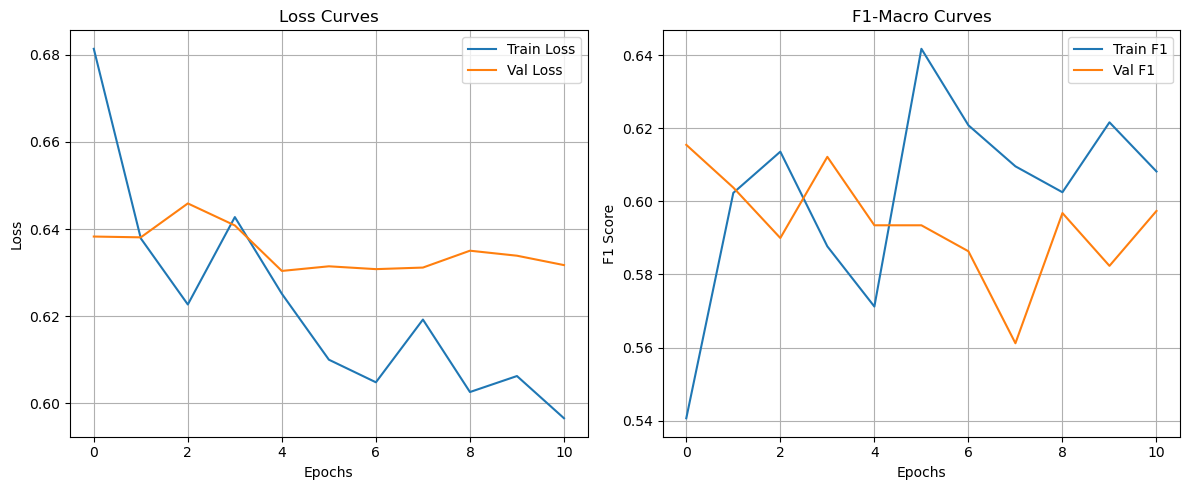

In [10]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['train_f1'], label='Train F1')
plt.plot(history['val_f1'], label='Val F1')
plt.title('F1-Macro Curves')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 10. Hyperparameter Tuning with Optuna (MLP)

We systematically search for the best combination of hyperparameters using Bayesian Optimization (Optuna), maximizing the validation **F1-macro** score.

In [11]:
# Install Optuna if not already installed
!pip install optuna
import optuna

def objective(trial):
    # 1. Suggest hyperparameters
    batch_size = trial.suggest_categorical('batch_size', [4, 8, 16, 32])
    lr = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)
    dropout_rate = trial.suggest_float('dropout', 0.1, 0.6)
    
    # 2. Rebuild loaders
    trainloader_conf = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True) #drop_last to prevent showing up an error when computing variance with 1 training sample
    valloader_conf = DataLoader(val_dataset, batch_size=batch_size, shuffle=False) # Keep drop_last=False
    
    # 3. Create model, optimizer, scheduler, criterion
    model_conf = FCMLP(input_dim=len(fc_cols), dropout_rate=dropout_rate).to(device)
    optimizer_conf = optim.Adam(model_conf.parameters(), lr=lr)
    scheduler_conf = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_conf, mode='min', factor=0.1, patience=3)
    criterion = nn.CrossEntropyLoss()
    
    # 4. Training loop (with Optuna pruning)
    best_val_f1 = 0.0
    for epoch in range(30):
        model_conf.train()
        for inputs, labels in trainloader_conf:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer_conf.zero_grad()
            outputs = model_conf(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer_conf.step()
            
        model_conf.eval()
        val_preds, val_labels = [], []
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in valloader_conf:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model_conf(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_preds.extend(predicted.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())
                
        epoch_val_loss = val_loss / len(valloader_conf)
        epoch_val_f1 = f1_score(val_labels, val_preds, average='macro')
        
        scheduler_conf.step(epoch_val_loss)
        
        if epoch_val_f1 > best_val_f1:
            best_val_f1 = epoch_val_f1
            
        # Report intermediate value for pruning
        trial.report(epoch_val_f1, epoch)
        
        # Handle pruning
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
            
    return best_val_f1

In [12]:
# Run Optuna Study maximizing F1-macro score
optuna.logging.set_verbosity(optuna.logging.INFO)
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, timeout=600)

print("OPTUNA STUDY COMPLETE")
print(f"Best Trial F1-Macro: {study.best_value:.4f}")
print(f"Best Parameters: {study.best_params}")

[I 2026-06-08 18:11:52,155] A new study created in memory with name: no-name-0c453adf-8e26-455d-bfe1-795b10a6af86
[I 2026-06-08 18:11:55,184] Trial 0 finished with value: 0.6194433854365231 and parameters: {'batch_size': 16, 'learning_rate': 0.0007584732439562605, 'dropout': 0.5915522437196467}. Best is trial 0 with value: 0.6194433854365231.
[I 2026-06-08 18:12:00,995] Trial 1 finished with value: 0.5930714567706277 and parameters: {'batch_size': 8, 'learning_rate': 2.805106045079984e-05, 'dropout': 0.5391610209373848}. Best is trial 0 with value: 0.6194433854365231.
[I 2026-06-08 18:12:06,764] Trial 2 finished with value: 0.6123495145631068 and parameters: {'batch_size': 8, 'learning_rate': 0.0026565015919276145, 'dropout': 0.48150359020001976}. Best is trial 0 with value: 0.6194433854365231.
[I 2026-06-08 18:12:08,378] Trial 3 finished with value: 0.4670712773465067 and parameters: {'batch_size': 32, 'learning_rate': 1.0060155132549146e-05, 'dropout': 0.24887286729257022}. Best is t

OPTUNA STUDY COMPLETE
Best Trial F1-Macro: 0.6554
Best Parameters: {'batch_size': 16, 'learning_rate': 0.00015871336129294068, 'dropout': 0.20699976785720092}


In [13]:
# Print study trials summary
study_df = study.trials_dataframe()
print("OPTUNA STUDY SUMMARY (SORTED BY VAL F1)")
print(study_df.sort_values(by='value', ascending=False)[['number', 'value', 'params_batch_size', 'params_learning_rate', 'params_dropout', 'state']].head(10).to_string(index=False))

OPTUNA STUDY SUMMARY (SORTED BY VAL F1)
 number    value  params_batch_size  params_learning_rate  params_dropout    state
     12 0.655384                 16              0.000159        0.207000 COMPLETE
      9 0.631765                 16              0.000104        0.219582 COMPLETE
      4 0.629060                 16              0.000041        0.263142 COMPLETE
     20 0.627419                 16              0.000558        0.133900 COMPLETE
      5 0.623814                  4              0.000115        0.282028 COMPLETE
      8 0.621347                 16              0.001446        0.530608 COMPLETE
     23 0.621347                 16              0.000132        0.228573 COMPLETE
     27 0.620408                 32              0.000399        0.209383 COMPLETE
     15 0.619443                 16              0.000526        0.182304 COMPLETE
      0 0.619443                 16              0.000758        0.591552 COMPLETE


## 11. Final Model Retraining & Test Evaluation (MLP)

We retrain the model with the best parameters found during Grid Search and evaluate its final classification performance (maximizing F1-macro) on the unseen test dataset.

In [14]:
# Identify best configuration from Optuna
best_batch_size = int(study.best_params['batch_size'])
best_lr = float(study.best_params['learning_rate'])
best_dropout = float(study.best_params['dropout'])

print(f"Best Configuration: Batch Size = {best_batch_size}, LR = {best_lr}, Dropout = {best_dropout}")

# 1. Rebuild loaders with best batch size
train_loader_best = DataLoader(train_dataset, batch_size=best_batch_size, shuffle=True, drop_last=True)
val_loader_best = DataLoader(val_dataset, batch_size=best_batch_size, shuffle=False)
test_loader_best = DataLoader(test_dataset, batch_size=best_batch_size, shuffle=False)

# 2. Re-instantiate model, optimizer, scheduler, criterion
model_best = FCMLP(input_dim=len(fc_cols), dropout_rate=best_dropout).to(device)
optimizer_best = optim.Adam(model_best.parameters(), lr=best_lr)
scheduler_best = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_best, mode='min', factor=0.1, patience=3)
criterion_best = nn.CrossEntropyLoss()

# 3. Retrain model
print("\nRetraining model with best hyperparameters...")
history_best = train_model(
    model=model_best,
    train_loader=train_loader_best,
    val_loader=val_loader_best,
    criterion=criterion_best,
    optimizer=optimizer_best,
    scheduler=scheduler_best,
    device=device,
    epochs=50,
    epoch_details=True
)

# 4. Generate predictions on test set
model_best.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader_best:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_best(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# 5. Compute test metrics
mlp_test_accuracy = accuracy_score(all_labels, all_preds)
mlp_test_f1 = f1_score(all_labels, all_preds, average='macro')

print(f"\nMLP Test Accuracy: {mlp_test_accuracy * 100:.2f}%")
print(f"MLP Test F1-Macro: {mlp_test_f1:.4f}")
print("\nMLP Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

Best Configuration: Batch Size = 16, LR = 0.00015871336129294068, Dropout = 0.20699976785720092

Retraining model with best hyperparameters...
Epoch 1/50: Train Loss: 0.7293 Acc: 50.47% F1: 0.5043 | Val Loss: 0.6841 Acc: 53.92% F1: 0.5391
SAVED model so far) (Best Val F1: 0.5391)
Epoch 2/50: Train Loss: 0.6679 Acc: 59.53% F1: 0.5906 | Val Loss: 0.6659 Acc: 58.99% F1: 0.5723
SAVED model so far) (Best Val F1: 0.5723)
Epoch 3/50: Train Loss: 0.6428 Acc: 60.16% F1: 0.5830 | Val Loss: 0.6614 Acc: 58.99% F1: 0.5723
Epoch 4/50: Train Loss: 0.6382 Acc: 62.19% F1: 0.5953 | Val Loss: 0.6529 Acc: 59.91% F1: 0.5659
Epoch 5/50: Train Loss: 0.6335 Acc: 63.59% F1: 0.5978 | Val Loss: 0.6478 Acc: 62.21% F1: 0.5823
SAVED model so far) (Best Val F1: 0.5823)
Epoch 6/50: Train Loss: 0.6260 Acc: 66.25% F1: 0.6260 | Val Loss: 0.6416 Acc: 64.06% F1: 0.5918
SAVED model so far) (Best Val F1: 0.5918)
Epoch 7/50: Train Loss: 0.6172 Acc: 67.03% F1: 0.6229 | Val Loss: 0.6395 Acc: 66.36% F1: 0.6107
SAVED model so fa

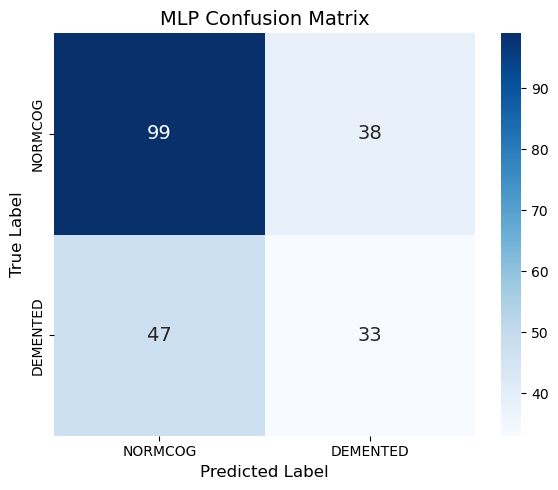

In [15]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 14})
plt.title('MLP Confusion Matrix', fontsize=14)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

## 12. Traditional Machine Learning Comparison with 10-Fold Cross-Validation

To compare our MLP model against traditional Machine Learning algorithms, we perform a **Grid Search** with **10-Fold Cross-Validation** for both a Support Vector Machine (SVM) and a Random Forest Classifier, optimizing for the **F1-macro** score.

In [16]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# 1. Define Parameter Grids
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear', 'sigmoid']
}

rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 2. Initialize and run GridSearchCV with 10-Fold CV maximizing F1-macro
print("Running SVM Grid Search with 10-Fold CV...")
svm_grid = GridSearchCV(
    estimator=SVC(probability=True, random_state=34),
    param_grid=svm_param_grid,
    cv=10,
    scoring='f1_macro',
    n_jobs=-1
)
svm_grid.fit(X_train_fc, y_train)
best_svm = svm_grid.best_estimator_
print(f"Best SVM Params: {svm_grid.best_params_}")
print(f"Best SVM Train CV F1-macro: {svm_grid.best_score_:.4f}\n")

print("Running Random Forest Grid Search with 10-Fold CV...")
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=34),
    param_grid=rf_param_grid,
    cv=10,
    scoring='f1_macro',
    n_jobs=-1
)
rf_grid.fit(X_train_fc, y_train)
best_rf = rf_grid.best_estimator_
print(f"Best RF Params: {rf_grid.best_params_}")
print(f"Best RF Train CV F1-macro: {rf_grid.best_score_:.4f}")

Running SVM Grid Search with 10-Fold CV...
Best SVM Params: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best SVM Train CV F1-macro: 0.6082

Running Random Forest Grid Search with 10-Fold CV...
Best RF Params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
Best RF Train CV F1-macro: 0.6047


In [17]:
# Predict and evaluate optimized SVM on test set
y_pred_svm = best_svm.predict(X_test_fc)
svm_test_acc = accuracy_score(y_test, y_pred_svm)
svm_test_f1 = f1_score(y_test, y_pred_svm, average='macro')

print("--- OPTIMIZED SUPPORT VECTOR MACHINE (SVM) ---")
print(f"Test Accuracy: {svm_test_acc * 100:.2f}%")
print(f"Test F1-Macro: {svm_test_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=class_names))

# Predict and evaluate optimized Random Forest on test set
y_pred_rf = best_rf.predict(X_test_fc)
rf_test_acc = accuracy_score(y_test, y_pred_rf)
rf_test_f1 = f1_score(y_test, y_pred_rf, average='macro')

print("\n--- OPTIMIZED RANDOM FOREST ---")
print(f"Test Accuracy: {rf_test_acc * 100:.2f}%")
print(f"Test F1-Macro: {rf_test_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=class_names))

--- OPTIMIZED SUPPORT VECTOR MACHINE (SVM) ---
Test Accuracy: 62.67%
Test F1-Macro: 0.5609

Classification Report:
              precision    recall  f1-score   support

     NORMCOG       0.67      0.80      0.73       137
    DEMENTED       0.49      0.33      0.39        80

    accuracy                           0.63       217
   macro avg       0.58      0.56      0.56       217
weighted avg       0.60      0.63      0.61       217


--- OPTIMIZED RANDOM FOREST ---
Test Accuracy: 64.06%
Test F1-Macro: 0.5639

Classification Report:
              precision    recall  f1-score   support

     NORMCOG       0.67      0.84      0.75       137
    DEMENTED       0.52      0.30      0.38        80

    accuracy                           0.64       217
   macro avg       0.60      0.57      0.56       217
weighted avg       0.62      0.64      0.61       217



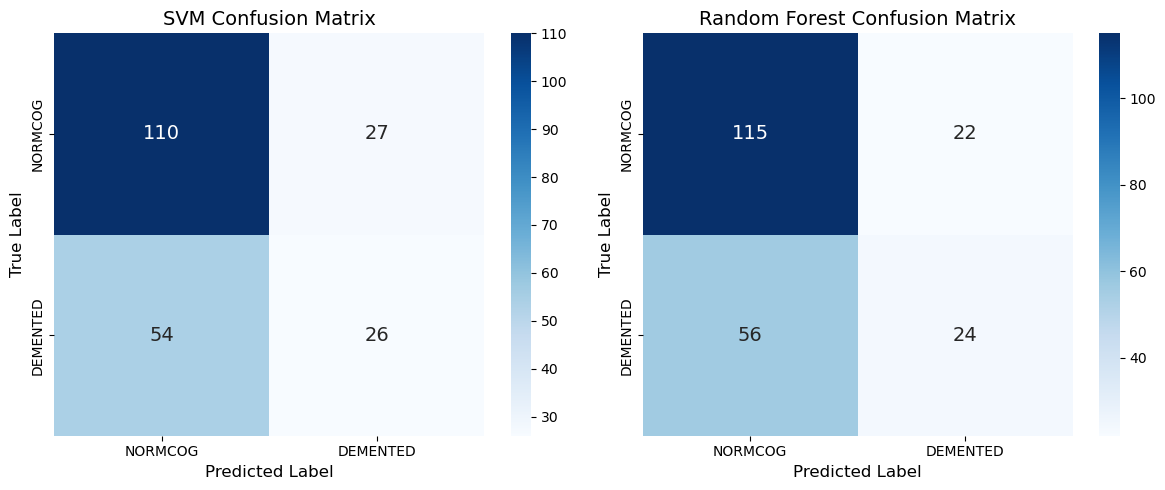

In [18]:
# Plot Confusion Matrices for SVM and Random Forest side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# SVM Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 14}, ax=axes[0])
axes[0].set_title('SVM Confusion Matrix', fontsize=14)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 14}, ax=axes[1])
axes[1].set_title('Random Forest Confusion Matrix', fontsize=14)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.show()

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 2 with shape (7,) and arg 3 with shape (15,).

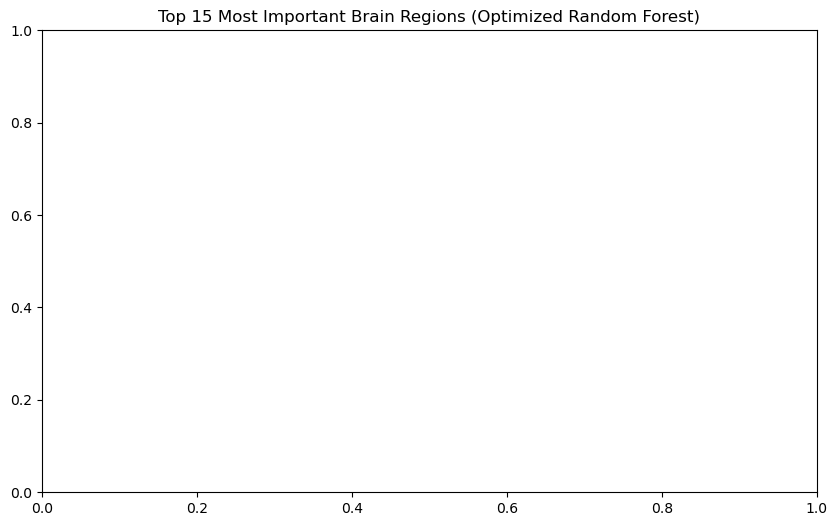

In [19]:
# Plot Feature Importances from the best Random Forest model
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot the top 15 features
plt.figure(figsize=(10, 6))
plt.title("Top 15 Most Important Brain Regions (Optimized Random Forest)")
plt.barh(range(15), importances[indices[:15]][::-1], align="center")
plt.yticks(range(15), [fc_cols[i] for i in indices[:15]][::-1])
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()

In [ ]:
# Overall Comparison Table
print("=== FINAL MODEL COMPARISON (TEST SET) ===")
print(f"Deep Learning MLP:       F1-Macro = {mlp_test_f1:.4f} | Accuracy = {mlp_test_accuracy * 100:.2f}%")
print(f"Support Vector Machine:  F1-Macro = {svm_test_f1:.4f} | Accuracy = {svm_test_acc * 100:.2f}%")
print(f"Random Forest:           F1-Macro = {rf_test_f1:.4f} | Accuracy = {rf_test_acc * 100:.2f}%")